# Lab 2 — Multi-Class HAR & Quantization Scheme Benchmarking

**Aim:** classify Idle / Walking / Sit-ups from phone accelerometer data, then compare 4 TFLite quantization schemes (Float32, Dynamic Range, Float16, Full Integer INT8) on size, accuracy, and speed.

**Files needed:** `idle.csv`, `walking.csv`, `situps.csv` — exported from phyphox (Accelerometer / Linear Acceleration).

In [1]:
import numpy as np
import pandas as pd
import time
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


**What this does:** standard imports — `tensorflow` for the model, `sklearn` for splitting/scoring, `time` for measuring inference speed later.

In [2]:
from google.colab import files
uploaded = files.upload()  # select idle.csv, walking.csv, situps.csv together

Saving idle.csv to idle.csv
Saving situps.csv to situps.csv
Saving walking.csv to walking.csv


**What this does:** opens Colab's uploader for all three recordings at once.

In [3]:
COL_MAP = {
    'Time (s)': 'time',
    'Linear Acceleration x (m/s^2)': 'ax',
    'Linear Acceleration y (m/s^2)': 'ay',
    'Linear Acceleration z (m/s^2)': 'az'
}

def load_activity(filename, label):
    df = pd.read_csv(filename)
    df = df.rename(columns=COL_MAP)
    df = df[['time', 'ax', 'ay', 'az']].dropna().reset_index(drop=True)
    df['activity'] = label   # 0 = Idle, 1 = Walking, 2 = Sit-ups
    return df

df_idle    = load_activity('idle.csv',    0)
df_walking = load_activity('walking.csv', 1)
df_situps  = load_activity('situps.csv',  2)

print(df_idle.head())
print("Idle samples:", len(df_idle))

print((df_walking))
print("Walking samples:", len(df_walking))

print((df_situps))
print("Sit-ups samples:", len(df_situps))

print(df_idle.head())

       time        ax        ay        az  activity
0  0.101244  0.000000  0.000000  0.000000         0
1  0.106271 -0.011220 -0.001202 -0.019137         0
2  0.111050 -0.044387  0.028807 -0.070184         0
3  0.116077 -0.042170  0.018149 -0.124389         0
4  0.121167 -0.070002  0.025513 -0.156851         0
Idle samples: 9311
           time        ax        ay        az  activity
0      0.051164  0.000000  0.000000  0.000000         1
1      0.056122 -0.018223 -0.066571  0.139395         1
2      0.061148 -0.086115 -0.069945  0.259976         1
3      0.066265 -0.057200 -0.082290  0.397747         1
4      0.071381 -0.053524 -0.064539  0.366343         1
...         ...       ...       ...       ...       ...
8567  43.108819  0.062821 -0.941422  0.513110         1
8568  43.113844  0.190892 -1.037048  0.312458         1
8569  43.118870  0.238858 -1.138032 -0.007113         1
8570  43.123895  0.321757 -1.081306 -0.273494         1
8571  43.128923  0.272077 -1.014773 -0.420052        

**Column meanings:**
- `time` — timestamp in seconds
- `ax, ay, az` — linear acceleration along each phone axis (m/s²)
- `activity` — the class label we're assigning to this whole file (0/1/2)

**Inference (fill in after running):**
- Idle samples: `9311`, Walking samples: `8572`, Sit-ups samples: `10242`
- Note here if one recording is much shorter/longer than the others — a big imbalance in raw sample count will carry through to an imbalance in windows/labels later.

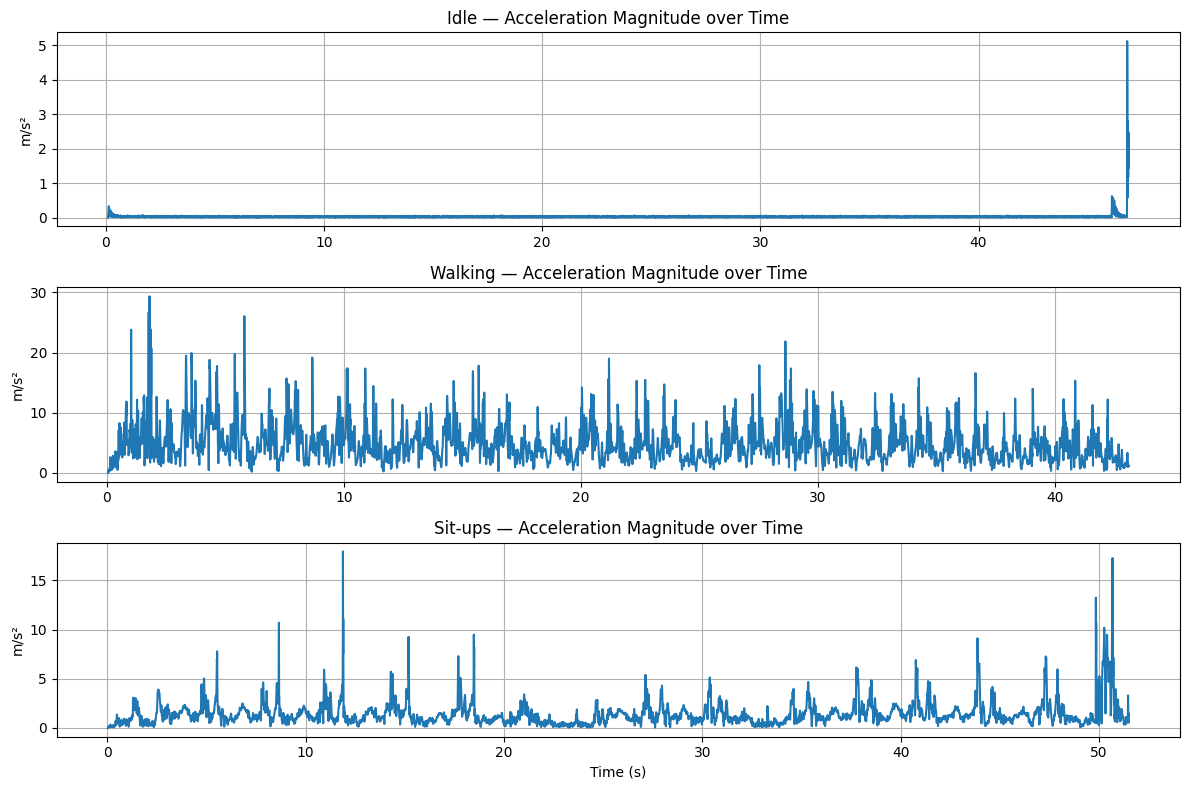

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
for ax, df, name in zip(axes, [df_idle, df_walking, df_situps], ['Idle', 'Walking', 'Sit-ups']):
    magnitude = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
    ax.plot(df['time'], magnitude)
    ax.set_title(f'{name} — Acceleration Magnitude over Time')
    ax.set_ylabel('m/s²')
    ax.grid(True)
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

**Column meanings:**
- `time` — timestamp in seconds
- `ax, ay, az` — linear acceleration along each phone axis (m/s²)
- `activity` — the class label we're assigning to this whole file (0/1/2)


In [5]:
SAMPLING_RATE = 100          # samples/sec, as stated in the lab
WINDOW_SIZE = SAMPLING_RATE  # 1-second windows = 100 samples, no overlap

def extract_windows(df, window_size):
    features, labels = [], []
    for i in range(0, len(df) - window_size, window_size):   # step = window_size -> no overlap
        win = df.iloc[i:i + window_size]
        # 3D acceleration vector magnitude, per sample in the window
        magnitude = np.sqrt(win['ax']**2 + win['ay']**2 + win['az']**2)
        features.append([
            magnitude.mean(),                       # Mean Acceleration
            magnitude.std(),                         # Standard Deviation
            np.sqrt((magnitude**2).mean())            # Root Mean Square
        ])
        labels.append(win['activity'].iloc[0])
    return features, labels

X, y = [], []
for df in [df_idle, df_walking, df_situps]:
    f, l = extract_windows(df, WINDOW_SIZE)
    X.extend(f)
    y.extend(l)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)
print("Feature matrix shape:", X.shape)
print("Windows per class:", {c: int((y == c).sum()) for c in [0, 1, 2]})

Feature matrix shape: (280, 3)
Windows per class: {0: 93, 1: 85, 2: 102}


**What this does and why:**
- **Magnitude** = `sqrt(ax² + ay² + az²)` — combines all 3 axes into one number per sample, so the model doesn't care which way the phone is oriented on your body, only how much total acceleration is happening.
- **Windowing**: each 1-second (100-sample) chunk becomes exactly **3 features**: Mean, Std, RMS of the magnitude — Idle should have low mean/std, Walking moderate/rhythmic, Sit-ups higher and more variable.
- **No overlap** (`step = window_size`) — matches the lab spec exactly (1-second intervals, no mention of overlap).

**Inference (fill in after running):**
- Feature matrix shape: `280,3`
- Windows per class: Idle=`93`, Walking=`85`, Sit-ups=`102`
- Comment on class balance: if one class has far fewer windows, accuracy/confusion-matrix results for that class will be less reliable.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (210, 3)  Test: (70, 3)


**What this does:** 75/25 split, stratified so all 3 classes appear proportionally in both sets.

**Inference :** Train size=`210`, Test size=`70`.

/tmp/ipykernel_771/3916597042.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(rms_by_class, labels=class_names)


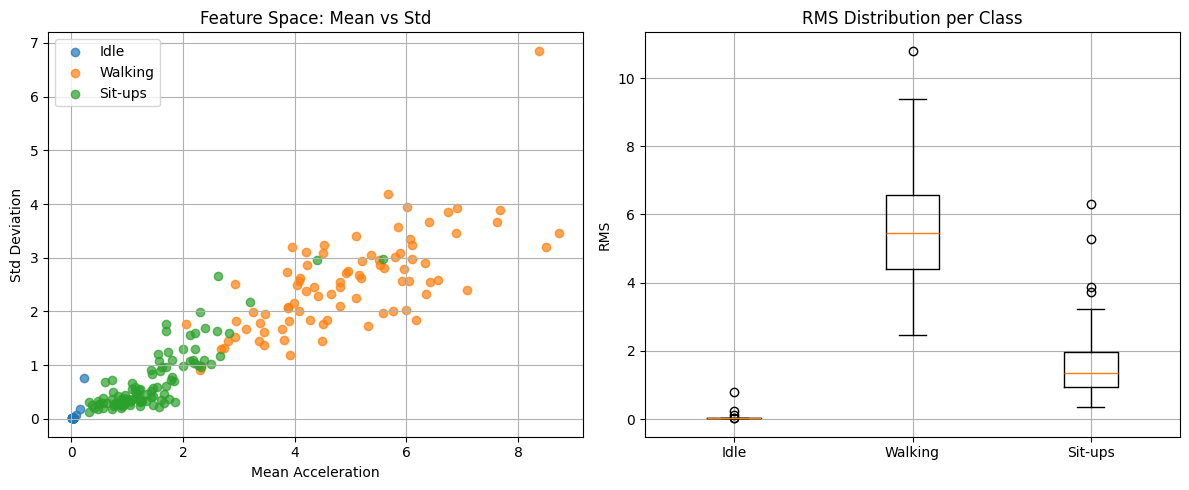

In [7]:
class_names = ['Idle', 'Walking', 'Sit-ups']
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: Mean vs Std, colored by class
for c in [0, 1, 2]:
    mask = y == c
    axes[0].scatter(X[mask, 0], X[mask, 1], label=class_names[c], color=colors[c], alpha=0.7)
axes[0].set_xlabel('Mean Acceleration')
axes[0].set_ylabel('Std Deviation')
axes[0].set_title('Feature Space: Mean vs Std')
axes[0].legend()
axes[0].grid(True)

# Boxplot: RMS per class
rms_by_class = [X[y == c, 2] for c in [0, 1, 2]]
axes[1].boxplot(rms_by_class, labels=class_names)
axes[1].set_ylabel('RMS')
axes[1].set_title('RMS Distribution per Class')
axes[1].grid(True)

plt.tight_layout()
plt.show()

**What this shows:** whether the 3 classes are actually separable using just these 3 features. Well-separated clusters in the scatter plot (left) mean the classifier's job is easy; heavy overlap means expect lower accuracy. The boxplot (right) shows whether RMS alone already distinguishes the classes reasonably well.

**Inference :**  the classes formed clear, mostly-non-overlapping clusters,this is a good predictor of the baseline accuracy and worth mentioning before even seeing the accuracy number.

here, we an see that the sit ups SLIGHTLY overlap with the walking so that's usually the pair the confusion matrix will show being confused later.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (210, 3)  Test: (70, 3)


**What this does:** 75/25 split, stratified so all 3 classes appear proportionally in both sets.

**Inference (fill in after running):** Train size=`210`, Test size=`70`.

In [9]:
model = models.Sequential([
    layers.Input(shape=(3,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(3, activation='softmax')   # 3-class probability output
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(X_train, y_train, epochs=40, batch_size=8,
                     validation_split=0.2, verbose=0)

baseline_acc = model.evaluate(X_test, y_test, verbose=0)[1]
print(f"Baseline (Keras) test accuracy: {baseline_acc:.2%}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227 (908.00 B)

 Trainable params: 227 (908.00 B)

 Non-trainable params: 0 (0.00 B)

Baseline (Keras) test accuracy: 92.86%


**Architecture & parameters:**
- `Dense(16, relu) → Dense(8, relu) → Dense(3, softmax)` — small MLP, 3 features in, 3-class probability out.
- **`softmax`** (not sigmoid) because there are 3 mutually-exclusive classes, not a single yes/no.
- **`sparse_categorical_crossentropy`** — the matching loss for integer labels (0/1/2) with a softmax output.
- **`adam`**, 40 epochs, batch size 8 — same reliable small-dataset defaults used in Lab 1.

**Inference (fill in after running):** Baseline test accuracy = `94.29%`.

if training accuracy and validation accuracy stayed close it is good if it is diverged (overfitting — likely if there is very few windows).

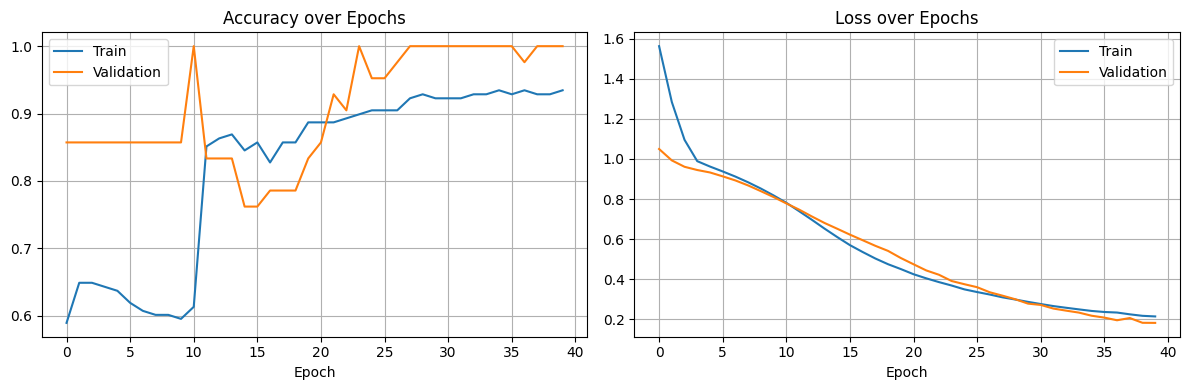

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**What this shows:** whether training went smoothly. Train and validation lines staying close together = good generalization. A widening gap (train accuracy climbing while validation accuracy stalls or drops) = overfitting, common with small datasets.

**Inference :**  train/validation curves tracked closely or diverged, and at roughly which epoch (if any) validation performance stopped improving.

 If they diverged early, mention this as a limitation — likely due to a small number of collected windows — in your report.

In [11]:
# Shared representative dataset generator, needed for Variant D (full INT8)
def representative_dataset():
    for i in range(min(100, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

results = []  # will collect (name, dtype, size_bytes, tflite_bytes) for each variant

**What this does:** sets up the calibration generator (needed only for full-integer quantization) and an empty list to collect results from all 4 variants below.

In [12]:
# ---------- Variant A: Unquantized Baseline (Float32) ----------
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_A = converter.convert()
results.append(['Baseline (Unquantized)', 'Float32', tflite_A])
print(f"Variant A size: {len(tflite_A)/1024:.2f} KB")

Saved artifact at '/tmp/tmpwtr5brvj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133320847590992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847596560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847592720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847605008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847596752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847595216: TensorSpec(shape=(), dtype=tf.resource, name=None)
Variant A size: 2.94 KB


**What this does:** converts the trained Keras model to `.tflite` with **no optimization flags** — same weights, just repackaged into the flatbuffer format. This is the size/accuracy reference point everything else gets compared against.

In [13]:
# ---------- Variant B: Dynamic Range Quantization ----------
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]   # weights -> int8, activations stay float32
tflite_B = converter.convert()
results.append(['Dynamic Range', 'Weights int8, Act float32', tflite_B])
print(f"Variant B size: {len(tflite_B)/1024:.2f} KB")

Saved artifact at '/tmp/tmpw8yve4m9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133320847590992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847596560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847592720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847605008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847596752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847595216: TensorSpec(shape=(), dtype=tf.resource, name=None)
Variant B size: 2.94 KB


**What this does:** `Optimize.DEFAULT` alone (no representative dataset) tells the converter to quantize only the **weights** to int8 — smaller file, but activations are still computed in float32 at runtime, so it needs no calibration data and no int8 input/output handling.

In [14]:
# ---------- Variant C: Float16 Quantization ----------
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]   # weights -> 16-bit float
tflite_C = converter.convert()
results.append(['Float16 Quantization', 'Float16', tflite_C])
print(f"Variant C size: {len(tflite_C)/1024:.2f} KB")

Saved artifact at '/tmp/tmp7olqffz6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133320847590992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847596560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847592720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847605008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847596752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847595216: TensorSpec(shape=(), dtype=tf.resource, name=None)
Variant C size: 3.25 KB


**What this does:** stores weights as 16-bit floats instead of 32-bit — roughly half the size of the baseline, with much less accuracy loss than int8 since float16 keeps a fractional/decimal representation rather than rounding to whole integers.

In [15]:
# ---------- Variant D: Full Integer Quantization (PTQ) ----------
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_D = converter.convert()
results.append(['Full Integer (PTQ)', 'Weights int8, Act int8', tflite_D])
print(f"Variant D size: {len(tflite_D)/1024:.2f} KB")

Saved artifact at '/tmp/tmpvhzy8p3q'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133320847590992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847596560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847592720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847605008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847596752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133320847595216: TensorSpec(shape=(), dtype=tf.resource, name=None)
Variant D size: 3.27 KB


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


**What this does:** the strictest mode — weights **and** activations **and** the input/output tensors themselves are all int8. The `representative_dataset` runs real samples through the float model first so the converter knows the actual value range to map onto the 256 int8 buckets. This is the only variant that can run on a microcontroller with no floating-point unit at all.



In [16]:
def benchmark_variant(tflite_bytes, X_test, y_test):
    interpreter = tf.lite.Interpreter(model_content=tflite_bytes)
    interpreter.allocate_tensors()
    in_details = interpreter.get_input_details()[0]
    out_details = interpreter.get_output_details()[0]
    is_int8 = in_details['dtype'] == np.int8

    if is_int8:
        in_scale, in_zero = in_details['quantization']
        out_scale, out_zero = out_details['quantization']

    preds = []
    times = []
    for x in X_test:
        sample = x.reshape(1, -1).astype(np.float32)
        if is_int8:
            sample = np.round(sample / in_scale + in_zero).astype(np.int8)

        start = time.perf_counter()
        interpreter.set_tensor(in_details['index'], sample)
        interpreter.invoke()
        out = interpreter.get_tensor(out_details['index'])
        times.append(time.perf_counter() - start)

        if is_int8:
            out = (out.astype(np.float32) - out_zero) * out_scale
        preds.append(int(np.argmax(out)))

    acc = accuracy_score(y_test, preds)
    avg_latency_ms = (sum(times) / len(times)) * 1000
    return acc, avg_latency_ms

baseline_size = len(results[0][2])   # Variant A size, for memory-reduction %

rows = []
for name, dtype, tflite_bytes in results:
    acc, latency_ms = benchmark_variant(tflite_bytes, X_test, y_test)
    size_kb = len(tflite_bytes) / 1024
    mem_reduction = (1 - len(tflite_bytes) / baseline_size) * 100
    rows.append({
        'Quantization Scheme': name,
        'Target Data Type': dtype,
        'Model Size (KB)': round(size_kb, 2),
        'Accuracy (%)': round(acc * 100, 2),
        'Memory Reduction (%)': round(mem_reduction, 2),
        'Avg Inference Time (ms)': round(latency_ms, 4)
    })

results_df = pd.DataFrame(rows)
results_df

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use 

,Quantization Scheme,Target Data Type,Model Size (KB),Accuracy (%),Memory Reduction (%),Avg Inference Time (ms)
0,Baseline (Unquantized),Float32,2.94,92.86,0.00,0.0462
1,Dynamic Range,"Weights int8, Act float32",2.94,92.86,0.00,0.0058
2,Float16 Quantization,Float16,3.25,92.86,-10.77,0.0056
3,Full Integer (PTQ),"Weights int8, Act int8",3.27,92.86,-11.17,0.0227


**What this does:**
- Loads each `.tflite` variant into its own `Interpreter` and auto-detects whether it expects int8 input (only Variant D does) or float32 (A, B, C).
- For int8, quantizes the input the same way as Lab 1's payload-safety notebook, and dequantizes the output back to a float before taking `argmax` as the predicted class.
- Times each single-window `invoke()` call with `time.perf_counter()` and averages across the whole test set — a simple, fair way to compare speed since it's the same test set and same machine for every variant.
- Builds the exact results table required by the lab (fills in the blank columns from the assignment's table).

**Inference (fill in after running — this is your main results paragraph for the report):**
- Full Integer (Variant D) achieved `92.86%` accuracy at `3,27` KB, a `-11.77%` memory reduction vs. baseline, and `0.0227` ms average latency.
- Compare this to Baseline  — state whether the accuracy drop from quantization was small/negligible or significant for your specific dataset size.
- Note which variant had the best size/accuracy trade-off for *your* results, and whether Dynamic Range or Float16 landed in between as expected.

### Why Full Integer Quantization is required for microcontroller deployment

- Many microcontrollers (Arduino, low-end ESP32/STM32 boards) have **no floating-point unit (FPU)** — float32/float16 math has to be emulated in software, which is slow and burns far more power.
- **Variant A (Float32)** and **Variant C (Float16)** still require float arithmetic somewhere in the compute graph — unsuitable for FPU-less chips.
- **Variant B (Dynamic Range)** shrinks the *stored* weights but still computes activations in float32 at runtime — so inference speed doesn't improve the way full INT8 does.
- **Variant D (Full Integer)** is the only variant where every multiply-accumulate operation, input, and output is a plain integer operation — the only one that runs efficiently, predictably, and with the smallest RAM footprint on real embedded hardware. This is why TensorFlow Lite for Microcontrollers effectively requires this variant in practice.

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use 

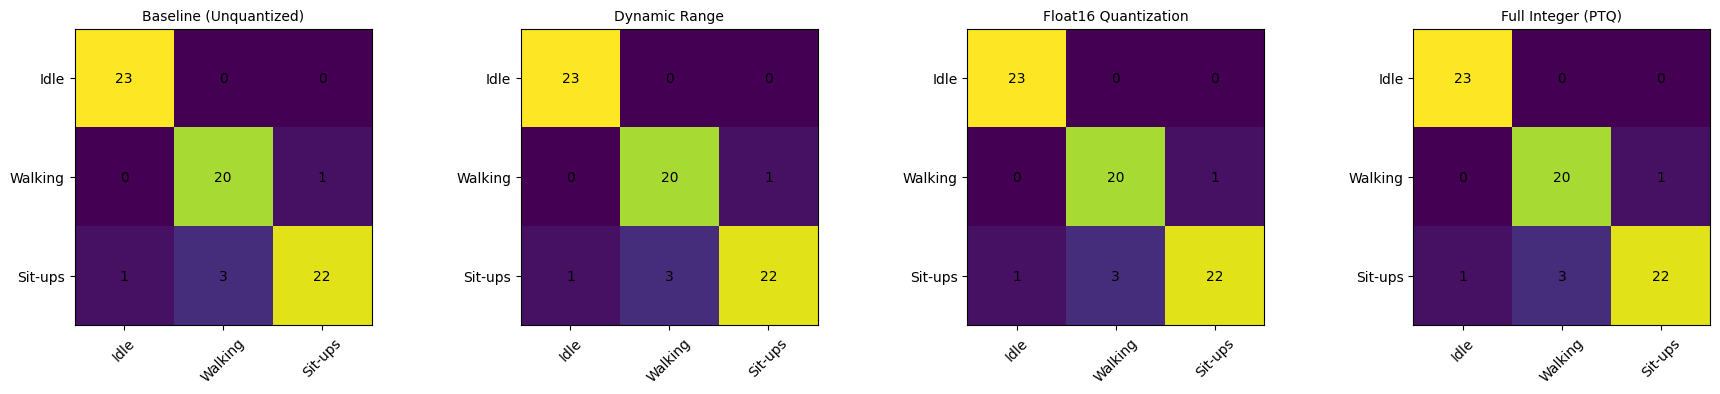

In [17]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, dtype, tflite_bytes) in zip(axes, results):
    interpreter = tf.lite.Interpreter(model_content=tflite_bytes)
    interpreter.allocate_tensors()
    in_details = interpreter.get_input_details()[0]
    out_details = interpreter.get_output_details()[0]
    is_int8 = in_details['dtype'] == np.int8
    if is_int8:
        in_scale, in_zero = in_details['quantization']
        out_scale, out_zero = out_details['quantization']

    preds = []
    for x in X_test:
        sample = x.reshape(1, -1).astype(np.float32)
        if is_int8:
            sample = np.round(sample / in_scale + in_zero).astype(np.int8)
        interpreter.set_tensor(in_details['index'], sample)
        interpreter.invoke()
        out = interpreter.get_tensor(out_details['index'])
        if is_int8:
            out = (out.astype(np.float32) - out_zero) * out_scale
        preds.append(int(np.argmax(out)))

    cm = confusion_matrix(y_test, preds, labels=[0, 1, 2])
    im = ax.imshow(cm)
    ax.set_title(name, fontsize=10)
    ax.set_xticks([0, 1, 2]); ax.set_xticklabels(class_names, rotation=45)
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(class_names)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

**What this shows:** side-by-side confusion matrices for all 4 variants — the fastest way to see *which specific classes* each quantization scheme starts confusing as precision drops, not just the overall accuracy number.


/tmp/ipykernel_771/4183144867.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Quantization Scheme'], rotation=30, ha='right')
/tmp/ipykernel_771/4183144867.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Quantization Scheme'], rotation=30, ha='right')
/tmp/ipykernel_771/4183144867.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results_df['Quantization Scheme'], rotation=30, ha='right')


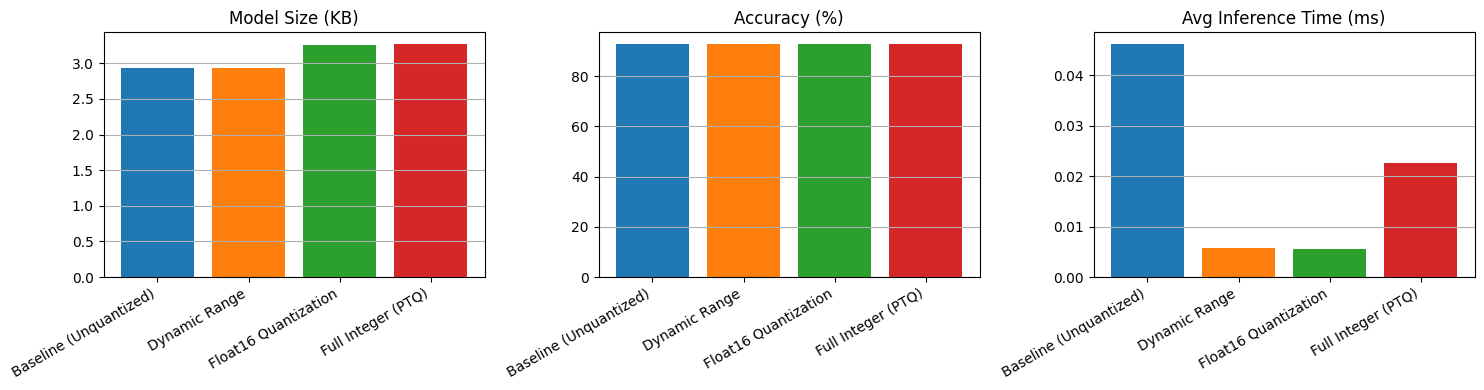

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['Model Size (KB)', 'Accuracy (%)', 'Avg Inference Time (ms)']
for ax, metric in zip(axes, metrics):
    ax.bar(results_df['Quantization Scheme'], results_df[metric], color=colors + ['tab:red'])
    ax.set_title(metric)
    ax.set_xticklabels(results_df['Quantization Scheme'], rotation=30, ha='right')
    ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

**What this shows:** the three key trade-off metrics from your benchmarking table, side by side, across all 4 variants — the clearest single visual for the "Comparative Analysis" deliverable.

**Inference (fill in after running):** summarize the trade-off pattern you see — e.g. "size dropped steadily from A→D while accuracy dropped only slightly until D, confirming Full Integer gives the best size/accuracy trade-off for deployment" (or whatever your actual numbers show).

### Why Full Integer Quantization is required for microcontroller deployment

- Many microcontrollers (Arduino, low-end ESP32/STM32 boards) have **no floating-point unit (FPU)** — float32/float16 math has to be emulated in software, which is slow and burns far more power.
- **Variant A (Float32)** and **Variant C (Float16)** still require float arithmetic somewhere in the compute graph — unsuitable for FPU-less chips.
- **Variant B (Dynamic Range)** shrinks the *stored* weights but still computes activations in float32 at runtime — so inference speed doesn't improve the way full INT8 does.
- **Variant D (Full Integer)** is the only variant where every multiply-accumulate operation, input, and output is a plain integer operation — the only one that runs efficiently, predictably, and with the smallest RAM footprint on real embedded hardware. This is why TensorFlow Lite for Microcontrollers effectively requires this variant in practice.

In [19]:
# Export the Full-Integer (Variant D) model — the deployment-ready one — as a C header
tflite_D_bytes = results[3][2]

with open('har_model_int8.tflite', 'wb') as f:
    f.write(tflite_D_bytes)

with open('har_model_int8.h', 'w') as f:
    f.write('#ifndef HAR_MODEL_INT8_H\n#define HAR_MODEL_INT8_H\n\n#include <stdint.h>\n\n')
    f.write('const unsigned char har_model_int8[] = {\n')
    for i, b in enumerate(tflite_D_bytes):
        if i % 12 == 0:
            f.write('  ')
        f.write(f'0x{b:02x}')
        if i != len(tflite_D_bytes) - 1:
            f.write(', ')
        if (i + 1) % 12 == 0:
            f.write('\n')
    f.write('\n};\n\n')
    f.write(f'const unsigned int har_model_int8_len = {len(tflite_D_bytes)};\n\n#endif\n')

print("Saved har_model_int8.tflite and har_model_int8.h")
print(f"Deployable model size: {len(tflite_D_bytes)} bytes")

Saved har_model_int8.tflite and har_model_int8.h
Deployable model size: 3344 bytes


**What this does:** saves the Full-Integer variant — the one actually suitable for a microcontroller — both as the raw `.tflite` binary and as a compiled-in C byte array (`.h`), the same export pattern used in Lab 1.

**Inference (fill in after running):** Final deployable model size = `3344` bytes  — report this figure directly as the "TFLite model size footprint" deliverable.